In [ ]:
# Cell 1: Install dependencies
!pip install ultralytics roboflow -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)


In [ ]:
# Cell 2: Check GPU
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
# Cell 3: Download COCO dataset
import os

!wget -q http://images.cocodataset.org/zips/train2017.zip
!wget -q http://images.cocodataset.org/zips/val2017.zip
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip

!unzip -q train2017.zip -d /content/coco/
!unzip -q val2017.zip -d /content/coco/
!unzip -q annotations_trainval2017.zip -d /content/coco/

print("COCO downloaded!")
print(f"Train images: {len(os.listdir('/content/coco/train2017'))}")
print(f"Val images: {len(os.listdir('/content/coco/val2017'))}")

COCO downloaded!
Train images: 118287
Val images: 5000


In [ ]:
# Cell 4: Convert COCO JSON labels to YOLOv8 format
import json
from pathlib import Path

def convert_coco_to_yolo(json_path, output_dir):
    with open(json_path) as f:
        data = json.load(f)

    os.makedirs(output_dir, exist_ok=True)

    images = {img['id']: img for img in data['images']}

    ann_by_image = {}
    for ann in data['annotations']:
        if ann.get('num_keypoints', 0) == 0:
            continue
        img_id = ann['image_id']
        if img_id not in ann_by_image:
            ann_by_image[img_id] = []
        ann_by_image[img_id].append(ann)

    for img_id, anns in ann_by_image.items():
        img = images[img_id]
        W, H = img['width'], img['height']
        filename = Path(img['file_name']).stem

        lines = []
        for ann in anns:
            x, y, w, h = ann['bbox']
            cx = (x + w/2) / W
            cy = (y + h/2) / H
            nw = w / W
            nh = h / H

            kpts = ann['keypoints']
            kpt_str = []
            for i in range(0, len(kpts), 3):
                kx = kpts[i] / W
                ky = kpts[i+1] / H
                kv = kpts[i+2]
                kpt_str.extend([f"{kx:.6f}", f"{ky:.6f}", str(kv)])

            line = f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f} " + " ".join(kpt_str)
            lines.append(line)

        if lines:
            with open(f"{output_dir}/{filename}.txt", 'w') as f:
                f.write("\n".join(lines))

    print(f"Done! Converted {len(ann_by_image)} images.")

convert_coco_to_yolo(
    '/content/coco/annotations/person_keypoints_train2017.json',
    '/content/coco_labels/train2017'
)

convert_coco_to_yolo(
    '/content/coco/annotations/person_keypoints_val2017.json',
    '/content/coco_labels/val2017'
)


Done! Converted 56599 images.
Done! Converted 2346 images.


In [ ]:
# Cell 5: Verify labels
print(f"Train labels: {len(os.listdir('/content/coco_labels/train2017'))}")
print(f"Val labels: {len(os.listdir('/content/coco_labels/val2017'))}")

Train labels: 56599
Val labels: 2346


In [ ]:
# Cell 6: Create dataset folder structure with symlinks
import shutil

os.makedirs('/content/coco_dataset/images/train2017', exist_ok=True)
os.makedirs('/content/coco_dataset/images/val2017', exist_ok=True)
os.makedirs('/content/coco_dataset/labels/train2017', exist_ok=True)
os.makedirs('/content/coco_dataset/labels/val2017', exist_ok=True)

shutil.copytree(
    '/content/coco_labels/train2017',
    '/content/coco_dataset/labels/train2017',
    dirs_exist_ok=True
)
shutil.copytree(
    '/content/coco_labels/val2017',
    '/content/coco_dataset/labels/val2017',
    dirs_exist_ok=True
)
print("Labels copied!")

for img in os.listdir('/content/coco/train2017'):
    src = f'/content/coco/train2017/{img}'
    dst = f'/content/coco_dataset/images/train2017/{img}'
    if not os.path.exists(dst):
        os.symlink(src, dst)

for img in os.listdir('/content/coco/val2017'):
    src = f'/content/coco/val2017/{img}'
    dst = f'/content/coco_dataset/images/val2017/{img}'
    if not os.path.exists(dst):
        os.symlink(src, dst)

print("Images symlinked!")
print(f"Train images: {len(os.listdir('/content/coco_dataset/images/train2017'))}")
print(f"Val images: {len(os.listdir('/content/coco_dataset/images/val2017'))}")

Labels copied!
Images symlinked!
Train images: 118287
Val images: 5000


In [ ]:
# Cell 7: Create yaml
import yaml

coco_pose_yaml = {
    'path': '/content/coco_dataset',
    'train': 'images/train2017',
    'val': 'images/val2017',
    'kpt_shape': [17, 3],
    'flip_idx': [0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13, 16, 15],
    'names': {0: 'person'}
}

with open('/content/coco-pose-custom.yaml', 'w') as f:
    yaml.dump(coco_pose_yaml, f)

print("YAML created!")

YAML created!


In [ ]:
# Cell 8: Train
from ultralytics import YOLO

model = YOLO("yolo26l-pose.pt")

results = model.train(
    data='/content/coco-pose-custom.yaml',
    fraction=0.4,
    epochs=50,
    imgsz=608,
    batch=16,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    patience=10,
    warmup_epochs=2,
    mosaic=1.0,
    mixup=0.0,
    degrees=15,
    flipud=0.05,
    project="/content/results",
    name="pose_coco",
    device=0,
    workers=4,
    pretrained=True,
    amp=True,
    plots=True,
    save=True,
    cos_lr=True,
)

Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/coco-pose-custom.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.05, format=torchscript, fraction=0.4, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=608, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26l-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pose_coco, nbs=64, nms=None, opset=None,

In [ ]:
# Cell 9: Save best model
import shutil
import os

os.makedirs('/content/saved_models', exist_ok=True)
shutil.copy(
    '/content/results/pose_coco/weights/best.pt',
    '/content/saved_models/best_model.pt'
)
print("Best model saved!")

metrics/precision(B) : 0.9586695093537394
metrics/recall(B) : 0.9606299212598425
metrics/mAP50(B) : 0.9907872266372767
metrics/mAP50-95(B) : 0.8255817967677294
metrics/precision(P) : 0.5714594756673016
metrics/recall(P) : 0.5196850393700787
metrics/mAP50(P) : 0.35688561380114253
metrics/mAP50-95(P) : 0.06756880339261194
fitness : 0.8931506001603413


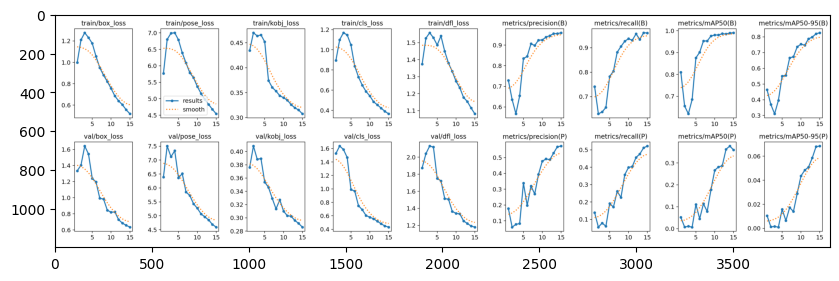

In [ ]:
from google.colab import files
files.download('/content/saved_models/best_model.pt')
print("Downloading best model...")

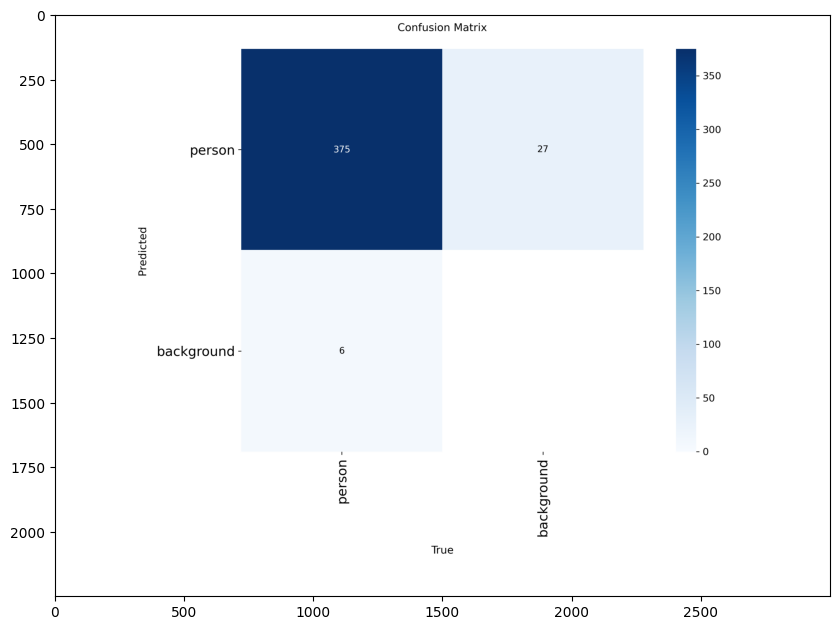

In [ ]:
# Cell 11: Print results
for key, value in results.results_dict.items():
    print(f"{key} : {value}")

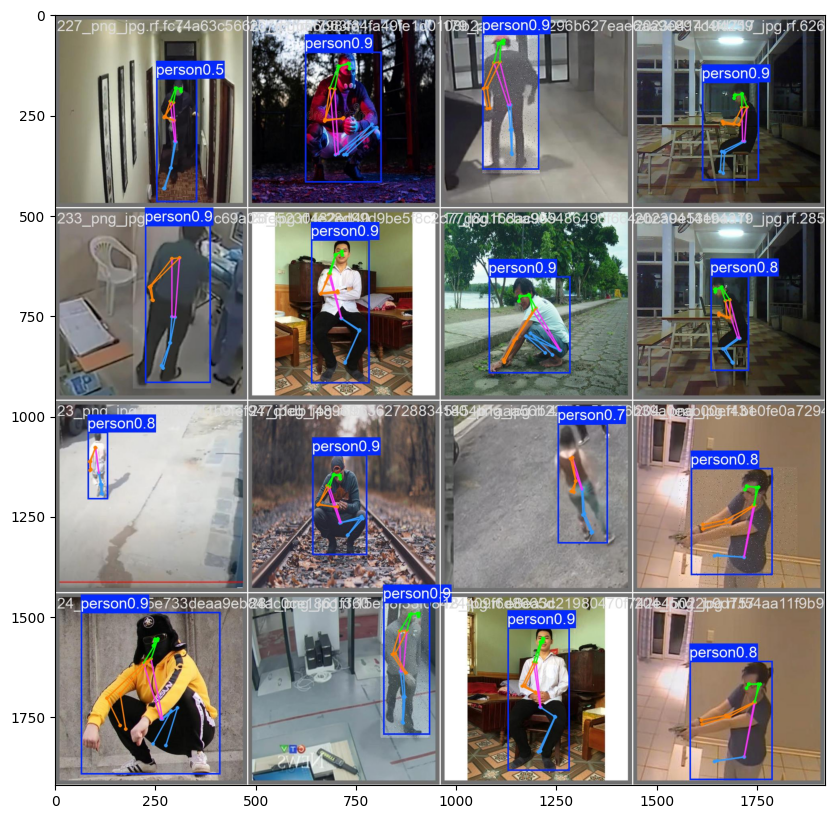

In [ ]:
# Cell 12: Visualize results
import matplotlib.pyplot as plt

img = plt.imread("/content/results/pose_coco/results.png")
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.show()

img = plt.imread("/content/results/pose_coco/confusion_matrix.png")
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.show()

img = plt.imread("/content/results/pose_coco/val_batch1_pred.jpg")
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.show()

In [ ]:
# Cell 13: Test on video
from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/best_model.pt')

# Upload your video first using the Colab file browser on the left
#results = model.predict(
#    source='/content/Brazen Gas Station Shootout Caught On Camera In St. Louis.mp4',   # change to your video filename
#    save=True,
#    stream=True,
#    conf=0.5,
#    project='/content/predictions',
#    name='video_test',
#    show_labels=True,
#    show_conf=True,
#)

#for r in results:
#    pass

#print("Done! Video saved.")
# Cell 6: Run prediction

results = model.predict(
    source='/content/construction.mp4',
    conf=0.25,
    imgsz=1280,
    iou=0.45,
    stream=True,
    save=True,
    project='/content/predictions',
    name='video_test',
    show_labels=True,
    show_conf=True,
)

for r in results:
    pass

print("Done!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

video 1/1 (frame 1/781) /content/construction.mp4: 1280x736 1 person, 98.9ms
video 1/1 (frame 2/781) /content/construction.mp4: 1280x736 2 persons, 74.9ms
video 1/1 (frame 3/781) /content/construction.mp4: 1280x736 3 persons, 61.0ms
video 1/1 (frame 4/781) /content/construction.mp4: 1280x736 2 persons, 62.9ms
video 1/1 (frame 5/781) /content/construction.mp4: 1280x736 1 person, 60.0ms
video 1/1 (frame 6/781) /content/construction.mp4: 1280x736 2 persons, 61.4ms
video 1/1 (frame 7/781) /content/construction.mp4: 1280x736 3 persons, 61.4ms
video 1/1 (frame 8/781) /content/construction.mp4: 1280x736 2 persons, 60.7ms
video 1/1 (frame 9/781) /content/construction.mp4: 1280x736 2 persons, 61.8ms
video 1/1 (frame 10/781) /content/construction.mp4: 1280x736 3 persons, 64.0ms
video 1/1 (frame 11/781) /content/construction.mp4: 1280x736 3 persons, 61.7ms
video 1/1 (f

In [ ]:
# Cell 14: Download output video
from google.colab import files
files.download('/content/predictions/video_test/your_video.mp4')  # change filename